🔍 EXTRACTING DATA FROM OLD CHECKPOINTS
✅ Extracted Random Forest...
    ⚠️ Warning: No test_indices for Random Forest, falling back to tail-end mapping.
✅ Extracted RoBERTa...
    ⚠️ Warning: No test_indices for RoBERTa, falling back to tail-end mapping.
✅ Extracted Gradient Boosting...
    ⚠️ Warning: No test_indices for Gradient Boosting, falling back to tail-end mapping.
✅ Extracted Logistic Regression...
    ⚠️ Warning: No test_indices for Logistic Regression, falling back to tail-end mapping.
✅ Extracted BERT...
    ⚠️ Warning: No test_indices for BERT, falling back to tail-end mapping.
✅ Extracted DistilBERT...
    ⚠️ Warning: No test_indices for DistilBERT, falling back to tail-end mapping.
✅ Extracted Naive Bayes...
    ⚠️ Warning: No test_indices for Naive Bayes, falling back to tail-end mapping.
✅ Extracted LSTM...
    ⚠️ Warning: No test_indices for LSTM, falling back to tail-end mapping.

🔧 RECONSTRUCTING ENSEMBLES
-----------------------------------------------------------

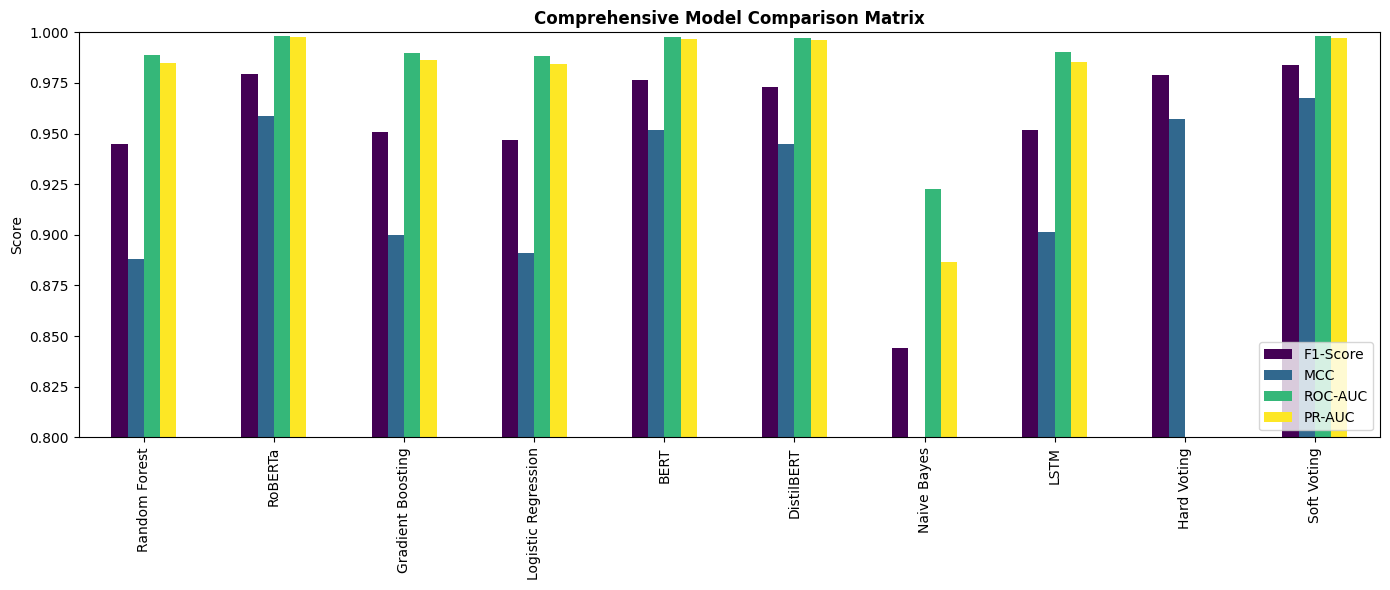

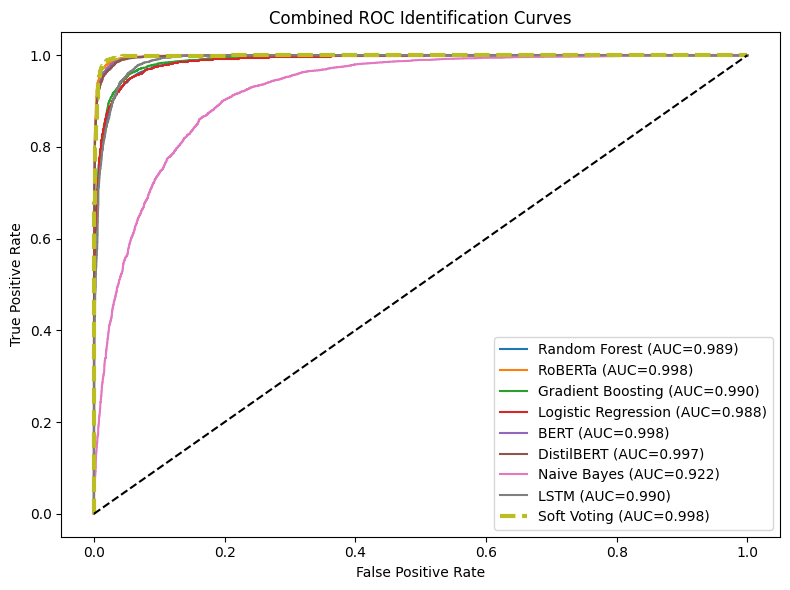

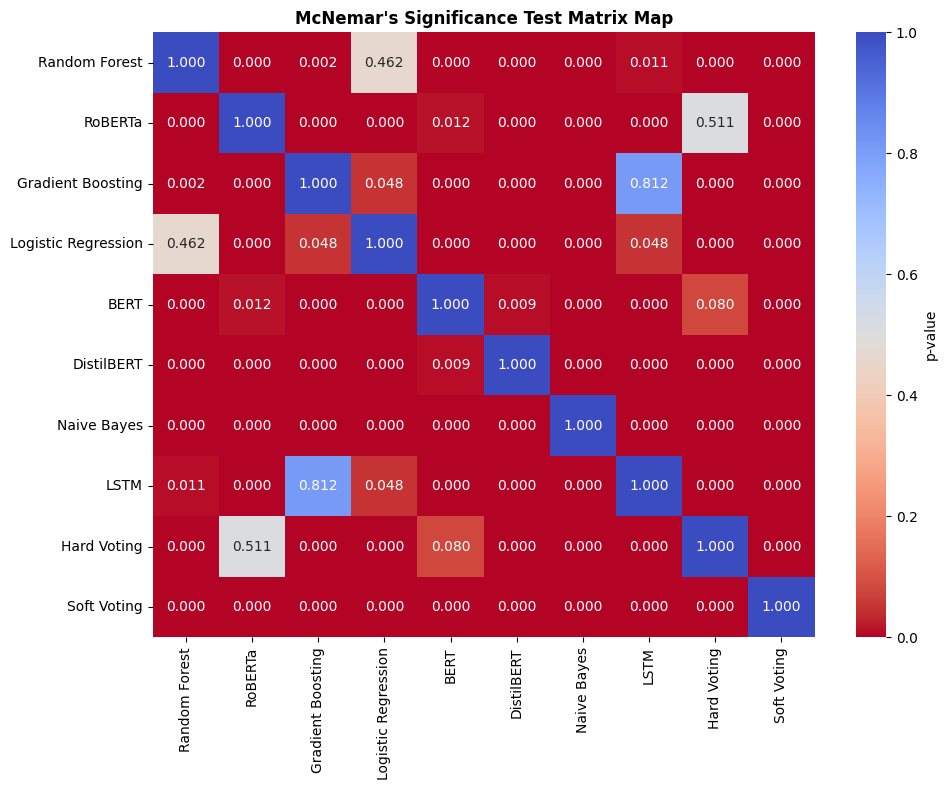

In [1]:
# generate_advanced_plots_from_old_run.py
# 🌟 [MODIFIED]: Now reads 'test_indices' for precise text mapping, logs bootstrap CI, includes Ensembles, and fixes Pandas KeyError.

import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, matthews_corrcoef,
                             average_precision_score, precision_recall_curve, roc_curve, auc,
                             brier_score_loss, balanced_accuracy_score)
from sklearn.calibration import calibration_curve
from statsmodels.stats.contingency_tables import mcnemar
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# CONFIGURATION
# =============================================================================
CHECKPOINT_DIR = "/kaggle/input/datasets/raghadwael21/662026-results/checkpoints" 
PLOTS_DIR = "/kaggle/working/advanced_plots"
COMBINED_DATA_PATH = "/kaggle/input/datasets/raghadwael21/662026-results/combined_dataset.csv" 

os.makedirs(PLOTS_DIR, exist_ok=True)

try:
    df_combined = pd.read_csv(COMBINED_DATA_PATH)
    text_mapping_available = True
except Exception:
    print("⚠️ Original combined dataset not found. Error Analysis WordClouds will be skipped.")
    text_mapping_available = False

# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================
def get_bootstrapped_ci(y_true, y_pred, n_bootstraps=1000):
    # 🌟 [ADDED]: Force conversion to numpy arrays to bypass Pandas KeyError
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    np.random.seed(42)
    metrics = {'f1': [], 'mcc': []}
    indices = np.arange(len(y_true))
    for _ in range(n_bootstraps):
        boot_idx = np.random.choice(indices, size=len(indices), replace=True)
        y_true_b, y_pred_b = y_true[boot_idx], y_pred[boot_idx]
        metrics['f1'].append(f1_score(y_true_b, y_pred_b, average='weighted', zero_division=0))
        metrics['mcc'].append(matthews_corrcoef(y_true_b, y_pred_b))
    return {k: (np.percentile(v, 2.5), np.percentile(v, 97.5)) for k, v in metrics.items() if v}

def plot_calibration_curve(y_true, y_scores, model_name):
    if y_scores is None: return
    prob_true, prob_pred = calibration_curve(y_true, y_scores, n_bins=10)
    brier = brier_score_loss(y_true, y_scores)
    plt.figure(figsize=(6, 5))
    plt.plot(prob_pred, prob_true, marker='o', label=f'{model_name} (Brier: {brier:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
    plt.title(f'Calibration Curve: {model_name}', fontweight='bold')
    plt.xlabel('Mean Predicted Probability'); plt.ylabel('Fraction of Positives')
    plt.legend(loc="lower right"); plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'calibration_{model_name.replace(" ", "_")}.png'), dpi=150); plt.close()

def save_roc_pr_curves(y_true, y_scores, model_name):
    if y_scores is None: return
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc(fpr, tpr):.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {model_name}', fontweight='bold'); plt.legend(loc="lower right"); plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'roc_{model_name.replace(" ", "_")}.png'), dpi=150); plt.close()

    # PR Curve
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {average_precision_score(y_true, y_scores):.4f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve: {model_name}', fontweight='bold'); plt.legend(loc="lower left"); plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'pr_{model_name.replace(" ", "_")}.png'), dpi=150); plt.close()

def perform_error_analysis(y_true, y_pred, y_scores, model_name, test_indices=None):
    if not text_mapping_available or y_scores is None: return
    try:
        if test_indices is not None:
            test_texts = df_combined.loc[test_indices, 'text'].values
        else:
            print(f"    ⚠️ Warning: No test_indices for {model_name}, falling back to tail-end mapping.")
            test_texts = df_combined['text'].iloc[-len(y_true):].values 
        
        df_err = pd.DataFrame({'text': test_texts, 'true_label': np.array(y_true), 'predicted_label': np.array(y_pred), 'prob_fake': np.array(y_scores)})
        fp = df_err[(df_err['true_label'] == 0) & (df_err['predicted_label'] == 1)].sort_values('prob_fake', ascending=False)
        fn = df_err[(df_err['true_label'] == 1) & (df_err['predicted_label'] == 0)].sort_values('prob_fake', ascending=True)
        
        fp.head(20).to_csv(os.path.join(PLOTS_DIR, f'error_FP_{model_name.replace(" ", "_")}.csv'), index=False)
        fn.head(20).to_csv(os.path.join(PLOTS_DIR, f'error_FN_{model_name.replace(" ", "_")}.csv'), index=False)
        
        if len(fp) > 0: WordCloud(width=800, height=400, background_color='white').generate(" ".join(fp['text'].astype(str))).to_file(os.path.join(PLOTS_DIR, f'wc_FP_{model_name.replace(" ", "_")}.png'))
        if len(fn) > 0: WordCloud(width=800, height=400, background_color='white').generate(" ".join(fn['text'].astype(str))).to_file(os.path.join(PLOTS_DIR, f'wc_FN_{model_name.replace(" ", "_")}.png'))
    except Exception as e:
        print(f"    ⚠️ WordCloud skipped for {model_name}: {e}")

# =============================================================================
# DATA EXTRACTION & EXECUTION
# =============================================================================
print("="*80)
print("🔍 EXTRACTING DATA FROM OLD CHECKPOINTS")
print("="*80)

all_results = {}
predictions_dict = {}
probability_dict = {}
pkl_files = [f for f in glob.glob(os.path.join(CHECKPOINT_DIR, "checkpoint_*.pkl")) if "ensemble" not in f]

if not pkl_files:
    print("❌ No base model checkpoints found. Please verify the CHECKPOINT_DIR path.")
    exit()

first_y_test = None

for pkl_file in pkl_files:
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)
        
        model_name = data.get('model_name', os.path.basename(pkl_file).replace('.pkl',''))
        res = data.get('results', {})
        
        if not res: continue
        
        y_true = res['y_test']
        y_pred = res['y_pred']
        test_indices = res.get('test_indices')
        
        if first_y_test is None: first_y_test = y_true
        
        raw_proba = res.get('y_pred_proba')
        if raw_proba is not None:
            if len(raw_proba.shape) == 2: y_scores = raw_proba[:, 1]
            else: y_scores = raw_proba
        else:
            y_scores = None

        mcc = matthews_corrcoef(y_true, y_pred)
        roc_auc_val = auc(*roc_curve(y_true, y_scores)[:2]) if y_scores is not None else np.nan
        pr_auc_val = average_precision_score(y_true, y_scores) if y_scores is not None else np.nan
        
        all_results[model_name] = {
            'y_true': y_true, 'y_pred': y_pred, 'y_scores': y_scores,
            'f1': res['f1'], 'mcc': mcc, 'roc_auc': roc_auc_val, 'pr_auc': pr_auc_val,
            'test_indices': test_indices
        }
        predictions_dict[model_name] = y_pred

        if y_scores is not None:
            probability_dict[model_name] = y_scores
        
        print(f"✅ Extracted {model_name}...")
        
        plot_calibration_curve(y_true, y_scores, model_name)
        save_roc_pr_curves(y_true, y_scores, model_name)
        perform_error_analysis(y_true, y_pred, y_scores, model_name, test_indices)

# Process Ensemble Checkpoint if it exists
ensemble_file = os.path.join(CHECKPOINT_DIR, "ensemble_results.pkl")
if os.path.exists(ensemble_file):
    with open(ensemble_file, 'rb') as f:
        ens_data = pickle.load(f)
    
    y_test_ens = ens_data['y_test']
    test_indices_ens = ens_data.get('test_indices')
    
    if ens_data.get('soft_proba') is not None:
        soft_pred = ens_data['soft_pred']
        soft_proba = ens_data['soft_proba']
        
        y_scores_soft = soft_proba[:, 1] if len(soft_proba.shape) == 2 else soft_proba
        
        all_results['Soft Voting'] = {
            'y_true': y_test_ens, 'y_pred': soft_pred, 'y_scores': y_scores_soft,
            'f1': f1_score(y_test_ens, soft_pred, average='weighted', zero_division=0),
            'mcc': matthews_corrcoef(y_test_ens, soft_pred),
            'roc_auc': auc(*roc_curve(y_test_ens, y_scores_soft)[:2]),
            'pr_auc': average_precision_score(y_test_ens, y_scores_soft),
            'test_indices': test_indices_ens
        }
        predictions_dict['Soft Voting'] = soft_pred
        print("✅ Extracted Soft Voting Ensemble...")
        plot_calibration_curve(y_test_ens, y_scores_soft, 'Soft Voting')
        save_roc_pr_curves(y_test_ens, y_scores_soft, 'Soft Voting')
        perform_error_analysis(y_test_ens, soft_pred, y_scores_soft, 'Soft Voting', test_indices_ens)


# =============================================================================
# RECONSTRUCT ENSEMBLES
# =============================================================================

print("\n🔧 RECONSTRUCTING ENSEMBLES")
print("-" * 80)

# --------------------------------------------------
# HARD VOTING
# --------------------------------------------------

try:

    model_preds = np.column_stack(
        [predictions_dict[m] for m in predictions_dict]
    )

    hard_pred = (
        np.sum(model_preds, axis=1)
        >= (model_preds.shape[1] / 2)
    ).astype(int)

    all_results["Hard Voting"] = {
        'y_true': first_y_test,
        'y_pred': hard_pred,
        'y_scores': None,
        'f1': f1_score(
            first_y_test,
            hard_pred,
            average='weighted',
            zero_division=0
        ),
        'mcc': matthews_corrcoef(
            first_y_test,
            hard_pred
        ),
        'roc_auc': np.nan,
        'pr_auc': np.nan,
        'test_indices': None
    }

    predictions_dict["Hard Voting"] = hard_pred

    print("✅ Generated Hard Voting Ensemble")

except Exception as e:

    print(f"⚠️ Hard Voting failed: {e}")

# --------------------------------------------------
# SOFT VOTING
# --------------------------------------------------

try:

    if len(probability_dict) > 0:

        model_probs = np.column_stack(
            [probability_dict[m] for m in probability_dict]
        )

        soft_proba = np.mean(
            model_probs,
            axis=1
        )

        soft_pred = (
            soft_proba >= 0.5
        ).astype(int)

        all_results["Soft Voting"] = {
            'y_true': first_y_test,
            'y_pred': soft_pred,
            'y_scores': soft_proba,
            'f1': f1_score(
                first_y_test,
                soft_pred,
                average='weighted',
                zero_division=0
            ),
            'mcc': matthews_corrcoef(
                first_y_test,
                soft_pred
            ),
            'roc_auc': auc(
                *roc_curve(
                    first_y_test,
                    soft_proba
                )[:2]
            ),
            'pr_auc': average_precision_score(
                first_y_test,
                soft_proba
            ),
            'test_indices': None
        }

        predictions_dict["Soft Voting"] = soft_pred

        print("✅ Generated Soft Voting Ensemble")

except Exception as e:

    print(f"⚠️ Soft Voting failed: {e}")
print("\n" + "="*80)
print("📊 GENERATING CROSS-MODEL COMPARISONS")
print("="*80)

print("\n📈 BOOTSTRAPPED CONFIDENCE INTERVALS")
print("-" * 80)
for m in all_results:
    ci = get_bootstrapped_ci(all_results[m]['y_true'], all_results[m]['y_pred'])
    print(f"{m}:")
    print(f"    F1 Score CI (95%): [{ci['f1'][0]:.4f}, {ci['f1'][1]:.4f}]")
    print(f"    MCC CI (95%):      [{ci['mcc'][0]:.4f}, {ci['mcc'][1]:.4f}]")

# 1. Comprehensive Bar Chart
metrics_df = pd.DataFrame({
    m: [all_results[m]['f1'], all_results[m]['mcc'], all_results[m]['roc_auc'], all_results[m]['pr_auc']] 
    for m in all_results
}).T
metrics_df.columns = ['F1-Score', 'MCC', 'ROC-AUC', 'PR-AUC']

metrics_df.plot(kind='bar', figsize=(14, 6), colormap='viridis')
plt.title('Comprehensive Model Comparison Matrix', fontweight='bold')
plt.ylabel('Score'); plt.ylim(0.8, 1.0); plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'compare_advanced_bar_chart.png'))
print("\n✅ Created Advanced Bar Chart")

# 2. Combined ROC Curves
plt.figure(figsize=(8, 6))
has_valid_roc = False
for m in all_results:
    if all_results[m]['y_scores'] is not None and not pd.isna(all_results[m]['roc_auc']):
        fpr, tpr, _ = roc_curve(all_results[m]['y_true'], all_results[m]['y_scores'])
        linewidth = 3 if 'Voting' in m else 1.5
        linestyle = '--' if 'Voting' in m else '-'
        plt.plot(fpr, tpr, lw=linewidth, ls=linestyle, label=f"{m} (AUC={all_results[m]['roc_auc']:.3f})")
        has_valid_roc = True

if has_valid_roc:
    plt.plot([0, 1], [0, 1], 'k--'); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.legend(); plt.title('Combined ROC Identification Curves'); plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'compare_combined_roc_curves.png'))
    print("✅ Created Combined ROC Chart")

# 3. McNemar's Significance Test Matrix Map
model_names = list(predictions_dict.keys())
p_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
y_test_base = np.array(first_y_test) # Force numpy here as well just in case

for i in range(len(model_names)):
    for j in range(len(model_names)):
        if i == j: p_matrix.iloc[i, j] = 1.0
        else:
            b_c1 = (np.array(predictions_dict[model_names[i]]) == y_test_base)
            b_c2 = (np.array(predictions_dict[model_names[j]]) == y_test_base)
            contingency_table = [[np.sum(b_c1 & b_c2), np.sum(b_c1 & ~b_c2)], 
                                 [np.sum(~b_c1 & b_c2), np.sum(~b_c1 & ~b_c2)]]
            p_matrix.iloc[i, j] = mcnemar(contingency_table, exact=False).pvalue

plt.figure(figsize=(10, 8))
sns.heatmap(p_matrix, annot=True, cmap='coolwarm_r', fmt=".3f", cbar_kws={'label': 'p-value'})
plt.title("McNemar's Significance Test Matrix Map", fontweight='bold'); plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'compare_mcnemar_heatmap.png'))
print("✅ Created McNemar Heatmap")

print(f"\n🎉 All advanced plots have been successfully generated in: {PLOTS_DIR}")